In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt


In [2]:
givenWkdir = '/datacopy/'
df_optimumK=pd.read_csv("BestKvalueCluster_VT.csv")
df_ssdeepClusters=pd.read_csv("/home/mabon/research/Autoyara/YaraResults/clusterCSV/sdhash/Th90.csv")
df_ssdeepClusters['File_Path'] = df_ssdeepClusters['File_Path'].str.replace('/usr/src/app/HDDdata/data/Windows/', givenWkdir, regex=False)
df_vtfam=pd.read_csv("/home/mabon/research/Autoyara/YaraResults/clusterCSV/virusTotal/MainVtCluster.csv")
df_vtfam['File_Path'] = df_vtfam['File_Path'].str.replace('/mnt/data_disk1/mabon/datacopy/', givenWkdir, regex=False)
unique_paths_b = df_vtfam['File_Path'].unique()
df_ssdeepClusters=df_ssdeepClusters[df_ssdeepClusters['File_Path'].isin(unique_paths_b)]

In [3]:
from tqdm import tqdm
import os
import pandas as pd

# Step 2: Function to extract file name from File_Path
def extract_file_name(file_path):
    return os.path.basename(file_path)

# Initialize lists to store new DataFrame data
result_data = {
    'File_Name': [],
    'Cluster_Label_A': [],
    'Cluster_Label_B': [],
    'File_Path_A': [],
    'File_Path_B': []
}

# Group File_Path by Cluster_Label in Dataframe A
cluster_paths = df_ssdeepClusters.groupby('Cluster_Label')['File_Path'].apply(list).to_dict()

# Iterate through each Cluster_Label and File_Path in Dataframe A
for cluster_label, paths in tqdm(cluster_paths.items(), desc="Processing Clusters"):
    for path in paths:
        file_name = extract_file_name(path)
        # Find matching row in Dataframe B
        matching_row = df_vtfam[df_vtfam['File_Name'] == file_name]
        if not matching_row.empty:
            # Match found, append data
            result_data['File_Name'].append(file_name)
            result_data['Cluster_Label_A'].append(cluster_label)
            result_data['Cluster_Label_B'].append(matching_row['Cluster_Label'].iloc[0])
            result_data['File_Path_A'].append(path)
            result_data['File_Path_B'].append(matching_row['File_Path'].iloc[0])
        else:
            # No match, append with None for Dataframe B columns
            result_data['File_Name'].append(file_name)
            result_data['Cluster_Label_A'].append(cluster_label)
            result_data['Cluster_Label_B'].append(None)
            result_data['File_Path_A'].append(path)
            result_data['File_Path_B'].append(None)
# Create new DataFrame
df_result = pd.DataFrame(result_data)


Processing Clusters: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4909/4909 [00:44<00:00, 109.71it/s]


In [4]:
df_result

,File_Name,Cluster_Label_A,Cluster_Label_B,File_Path_A,File_Path_B
0,SVia234_dsfgsdfgsg.exe,1,170,/datacopy/BB/Files/2017-04-11/SVia234_dsfgsdfg...,/datacopy/BB/Files/2017-04-11/SVia234_dsfgsdfg...
1,Cobranca_Boleto_Gestao-N000RR0029SSS3482xxl.com,1,10,/datacopy/BB/Files/2014-10-08/Cobranca_Boleto_...,/datacopy/BB/Files/2014-10-08/Cobranca_Boleto_...
2,4I2VhcvJ.exe,1,55,/datacopy/BB/Files/2013-12-12/4I2VhcvJ.exe,/datacopy/BB/Files/2013-12-12/4I2VhcvJ.exe
3,54bb4a414d8e4412e20f25a39e7602603cf2ee47.codex,1,310,/datacopy/CodexGiga/54bb4a414d8e4412e20f25a39e...,/datacopy/CodexGiga/54bb4a414d8e4412e20f25a39e...
4,b20543806dbb4e83b1510fe2c653aa2caebfc2fd.codex,1,310,/datacopy/CodexGiga/b20543806dbb4e83b1510fe2c6...,/datacopy/CodexGiga/b20543806dbb4e83b1510fe2c6...
...,...,...,...,...,...
16302,20568fce9e11b9aafdf500a64fba42e3bde72003.bin,8156,799,/datacopy/UCSB/20568fce9e11b9aafdf500a64fba42e...,/datacopy/UCSB/20568fce9e11b9aafdf500a64fba42e...
16303,cbf9b9aba62b997c5f280e64209e91ab72566e60.bin,8157,1528,/datacopy/UCSB/cbf9b9aba62b997c5f280e64209e91a...,/datacopy/UCSB/cbf9b9aba62b997c5f280e64209e91a...
16304,b87927ac988cc3b24102080e243ebd11d90d71cc.bin,8157,1528,/datacopy/UCSB/b87927ac988cc3b24102080e243ebd1...,/datacopy/UCSB/b87927ac988cc3b24102080e243ebd1...
16305,dcde1665b15eafbe4089fbb1205177efbfc65025.bin,8158,1773,/datacopy/UCSB/dcde1665b15eafbe4089fbb1205177e...,/datacopy/UCSB/dcde1665b15eafbe4089fbb1205177e...


In [5]:
# Create mapping from cluster number to best_k_value
k_map = df_optimumK.set_index('cluster_number')['best_k_value']

# Map and convert to int (after handling NaNs if any)
df_result['best_k_value'] = df_result['Cluster_Label_B'].map(k_map)

# Fill missing values with a default (e.g., 1), then convert to int
df_result['best_k_value'] = df_result['best_k_value'].fillna(1).astype(int)

In [6]:
df=df_result

In [ ]:

# Calculate cluster size for Cluster_Label_A
cluster_a_sizes = df['Cluster_Label_A'].value_counts().reset_index()
cluster_a_sizes.columns = ['Cluster_Label_A', 'Cluster_Size']

# Group by Cluster_Label_A and Cluster_Label_B to get unique best_k_value counts
k_value_counts = df.groupby('Cluster_Label_A')['Cluster_Label_B'].apply(lambda x: df[df['Cluster_Label_B'].isin(x)]['best_k_value'].nunique()).reset_index(name='Unique_K_Values')

# Merge the two dataframes
plot_data = pd.merge(cluster_a_sizes, k_value_counts, on='Cluster_Label_A')

# Scale point sizes based on Cluster_Size (adjust scaling factor as needed)
point_sizes = plot_data['Cluster_Size'] * 50

# Create a scatter plot
plt.figure(figsize=(10, 6))
# Plot main circles (scaled by cluster size)
plt.scatter(plot_data['Cluster_Size'], plot_data['Unique_K_Values'], s=point_sizes, alpha=0.6, c='teal', edgecolors='black', label='Cluster A')
# Plot center markers (small black dots)
plt.scatter(plot_data['Cluster_Size'], plot_data['Unique_K_Values'], s=10, c='black', marker='.', label='Center')
plt.xlabel('Cluster Size (Cluster_Label_A)')
plt.ylabel('Number of Unique best_k_value (from Cluster_Label_B)')
plt.title('Cluster Size of A vs. Number of Unique K Values from B')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

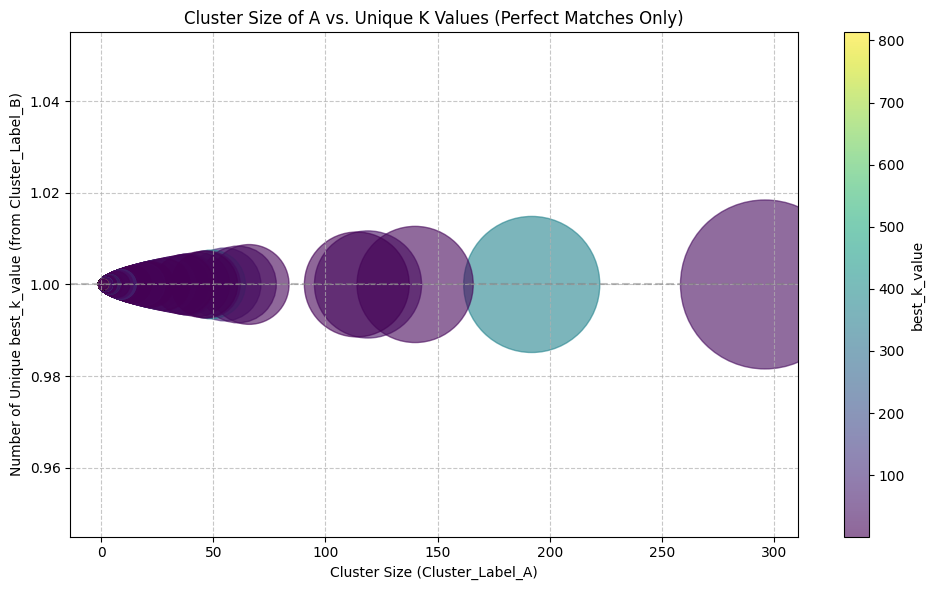

In [7]:
# Step 1: Group by Cluster_Label_A and check if all best_k_value are identical
k_value_counts = df.groupby('Cluster_Label_A').agg({
    'best_k_value': lambda x: x.nunique(),  # Count unique k-values
    'Cluster_Label_A': 'count'  # Count occurrences (cluster size)
}).rename(columns={'Cluster_Label_A': 'Cluster_Size', 'best_k_value': 'Unique_K_Values'}).reset_index()

# Step 2: Filter for Cluster_Label_A where all best_k_value are identical (Unique_K_Values == 1)
perfect_match_clusters = k_value_counts[k_value_counts['Unique_K_Values'] == 1]

# Step 3: Merge with the actual best_k_value for visualization (to color points)
k_values = df.groupby('Cluster_Label_A')['best_k_value'].first().reset_index()
plot_data = pd.merge(perfect_match_clusters, k_values, on='Cluster_Label_A')

# Step 4: Create a scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    plot_data['Cluster_Size'], 
    plot_data['Unique_K_Values'], 
    s=plot_data['Cluster_Size'] * 50,  # Scale point size by cluster size
    c=plot_data['best_k_value'],      # Color by best_k_value
    cmap='viridis', 
    alpha=0.6
)
plt.colorbar(label='best_k_value')
plt.xlabel('Cluster Size (Cluster_Label_A)')
plt.ylabel('Number of Unique best_k_value (from Cluster_Label_B)')
plt.title('Cluster Size of A vs. Unique K Values (Perfect Matches Only)')
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5)  # Highlight y=1
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
# Assuming df is your DataFrame
# Step 1: Count elements per Cluster_Label_A
cluster_counts = df['Cluster_Label_A'].value_counts().to_dict()

# Step 2: Filter rows where best_k_value >= cluster size
mask = df.apply(lambda row: row['best_k_value'] >= cluster_counts[row['Cluster_Label_A']], axis=1)

# Step 3: Drop those rows
df_filtered = df[~mask].reset_index(drop=True)

In [8]:
df_filtered

,File_Name,Cluster_Label_A,Cluster_Label_B,File_Path_A,File_Path_B,best_k_value
0,SVia234_dsfgsdfgsg.exe,1,170,/datacopy/BB/Files/2017-04-11/SVia234_dsfgsdfg...,/datacopy/BB/Files/2017-04-11/SVia234_dsfgsdfg...,1
1,Cobranca_Boleto_Gestao-N000RR0029SSS3482xxl.com,1,10,/datacopy/BB/Files/2014-10-08/Cobranca_Boleto_...,/datacopy/BB/Files/2014-10-08/Cobranca_Boleto_...,503
2,4I2VhcvJ.exe,1,55,/datacopy/BB/Files/2013-12-12/4I2VhcvJ.exe,/datacopy/BB/Files/2013-12-12/4I2VhcvJ.exe,543
3,54bb4a414d8e4412e20f25a39e7602603cf2ee47.codex,1,310,/datacopy/CodexGiga/54bb4a414d8e4412e20f25a39e...,/datacopy/CodexGiga/54bb4a414d8e4412e20f25a39e...,114
4,b20543806dbb4e83b1510fe2c653aa2caebfc2fd.codex,1,310,/datacopy/CodexGiga/b20543806dbb4e83b1510fe2c6...,/datacopy/CodexGiga/b20543806dbb4e83b1510fe2c6...,114
...,...,...,...,...,...,...
8463,2f9a63f1fb1aa4c0237a8ec23ec05d6a347aff6c.bin,8156,1564,/datacopy/UCSB/2f9a63f1fb1aa4c0237a8ec23ec05d6...,/datacopy/UCSB/2f9a63f1fb1aa4c0237a8ec23ec05d6...,1
8464,20568fce9e11b9aafdf500a64fba42e3bde72003.bin,8156,799,/datacopy/UCSB/20568fce9e11b9aafdf500a64fba42e...,/datacopy/UCSB/20568fce9e11b9aafdf500a64fba42e...,1
8465,cbf9b9aba62b997c5f280e64209e91ab72566e60.bin,8157,1528,/datacopy/UCSB/cbf9b9aba62b997c5f280e64209e91a...,/datacopy/UCSB/cbf9b9aba62b997c5f280e64209e91a...,1
8466,b87927ac988cc3b24102080e243ebd11d90d71cc.bin,8157,1528,/datacopy/UCSB/b87927ac988cc3b24102080e243ebd1...,/datacopy/UCSB/b87927ac988cc3b24102080e243ebd1...,1


In [9]:
# Group by Cluster_Label_A and transform best_k_value to max within each group
df_filtered['best_k_value'] = df_filtered.groupby('Cluster_Label_A')['best_k_value'].transform('max')


In [10]:
df_filtered=df_filtered.rename(columns={'File_Path_A': 'File_Path'})
df_filtered=df_filtered.drop(columns=['File_Path_B'])


In [11]:
df_filtered.to_csv("Maxk_heuristic_Th90.csv")

In [12]:
df_filtered

,File_Name,Cluster_Label_A,Cluster_Label_B,File_Path,best_k_value
0,SVia234_dsfgsdfgsg.exe,1,170,/datacopy/BB/Files/2017-04-11/SVia234_dsfgsdfg...,742
1,ProtestoAbril.doc.exe,1,2,/datacopy/BB/Files/2015-04-16/ProtestoAbril.do...,742
2,FOTOS20122.exe,1,2,/datacopy/BB/Files/2015-04-16/FOTOS20122.exe,742
3,bol_09112015.zip.exe,1,2,/datacopy/BB/Files/2015-11-11/bol_09112015.zip...,742
4,16.exe,1,9,/datacopy/BB/Files/2012-07-30/16.exe,742
...,...,...,...,...,...
11265,ebded3bd5ff0086aa78f1c254b0f238634aaf257.bin,8167,1629,/datacopy/UCSB/ebded3bd5ff0086aa78f1c254b0f238...,1
11266,5aa442c2b603311088eb603d89efb311f891012c.bin,8167,341,/datacopy/UCSB/5aa442c2b603311088eb603d89efb31...,1
11267,cbf9b9aba62b997c5f280e64209e91ab72566e60.bin,8168,1528,/datacopy/UCSB/cbf9b9aba62b997c5f280e64209e91a...,1
11268,b87927ac988cc3b24102080e243ebd11d90d71cc.bin,8168,1528,/datacopy/UCSB/b87927ac988cc3b24102080e243ebd1...,1
